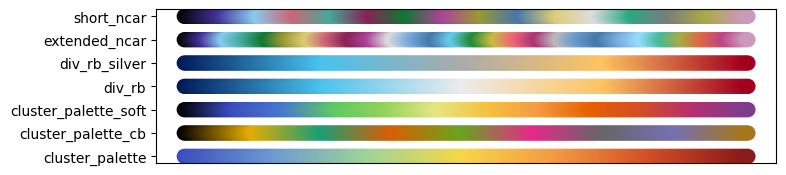

In [1]:
import os
import os.path as op
import importlib

import numpy as np

from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from time import perf_counter

import matplotlib.pyplot as plt

import sys
sys.path.append("../..")

from bimodularity import dgsp
from bimodularity import data_load as dload
from bimodularity import bundle as b_utils
from bimodularity.bimod_plots import add_cbar, plot_lobe_lines, get_all_cmaps

cmaps = get_all_cmaps()

In [2]:
path_to_brain_data = op.join("../../data", "brain")
path_to_derivatives = op.join(path_to_brain_data, "derivatives")

path_to_sc = op.join(path_to_derivatives, "structural_connectome")
path_to_ec = op.join(path_to_derivatives, "atlas_correspondence", "rDCM")
path_to_consensus = op.join(path_to_derivatives, "consensus_clustering")

path_to_lobe = op.join(path_to_derivatives, "atlas_correspondence", "Lobes")

In [ ]:
importlib.reload(dload)

path_to_rdcm = "/media/RCPNAS/HCP-data/HCP_rdcm"

print(f"Available Tasks: \n- {'\n- '.join(sorted(os.listdir(path_to_rdcm)))}")

filter_strength = 0
task_name = "DMN_AROMA_tfMRI_LANGUAGE_LR_MinReg_Laus2018_129S"
# task_name = "DMN_AROMA_tfMRI_MOTOR_LR_MinReg_Laus2018_129S"
# task_name = "DMN_AROMA_LexicalDecision_AllReg_Laus2018_129S"
# task_name = "DMN_FIX_rfMRI_REST1_LR_Laus2018_129S"

all_A_mats, all_C_mats = dload.prepare_task_ec(task_name, path_to_rdcm, filter_strength=filter_strength, verbose=True, njobs=20)
all_A_mats_bpa, all_C_mats_bpa = dload.prepare_task_ec(task_name, path_to_rdcm, filter_strength=filter_strength, bpa_combine=True, verbose=True, njobs=20)

Available Tasks: 
- DMN_AROMA_LexicalDecision_AllReg_Laus2018_129S
- DMN_AROMA_PictureNaming_AllReg_Laus2018_129S
- DMN_AROMA_SentenceComprehension_AllReg_Laus2018_129S
- DMN_AROMA_SentenceProduction_AllReg_Laus2018_129S
- DMN_AROMA_tfMRI_LANGUAGE_LR_AllReg_Laus2018_129S
- DMN_AROMA_tfMRI_LANGUAGE_LR_MinReg_Laus2018_129S
- DMN_AROMA_tfMRI_LANGUAGE_RL_AllReg_Laus2018_129S
- DMN_AROMA_tfMRI_LANGUAGE_RL_MinReg_Laus2018_129S
- DMN_AROMA_tfMRI_MOTOR_LR_MinReg_Laus2018_129S
- DMN_AROMA_tfMRI_MOTOR_RL_MinReg_Laus2018_129S
- DMN_FIX_rfMRI_REST1_LR_Laus2018_129S
- DMN_FIX_rfMRI_REST1_RL_Laus2018_129S
Found 100 subjects for task DMN_AROMA_tfMRI_LANGUAGE_LR_MinReg_Laus2018_129S


Loading DMN_AROMA_tfMRI_LANGUAGE_LR_MinReg_Laus2018_129S ...:   0%|          | 0/100 [00:00<?, ?it/s]

(-0.04466584963539296, 0.04466584963539296)

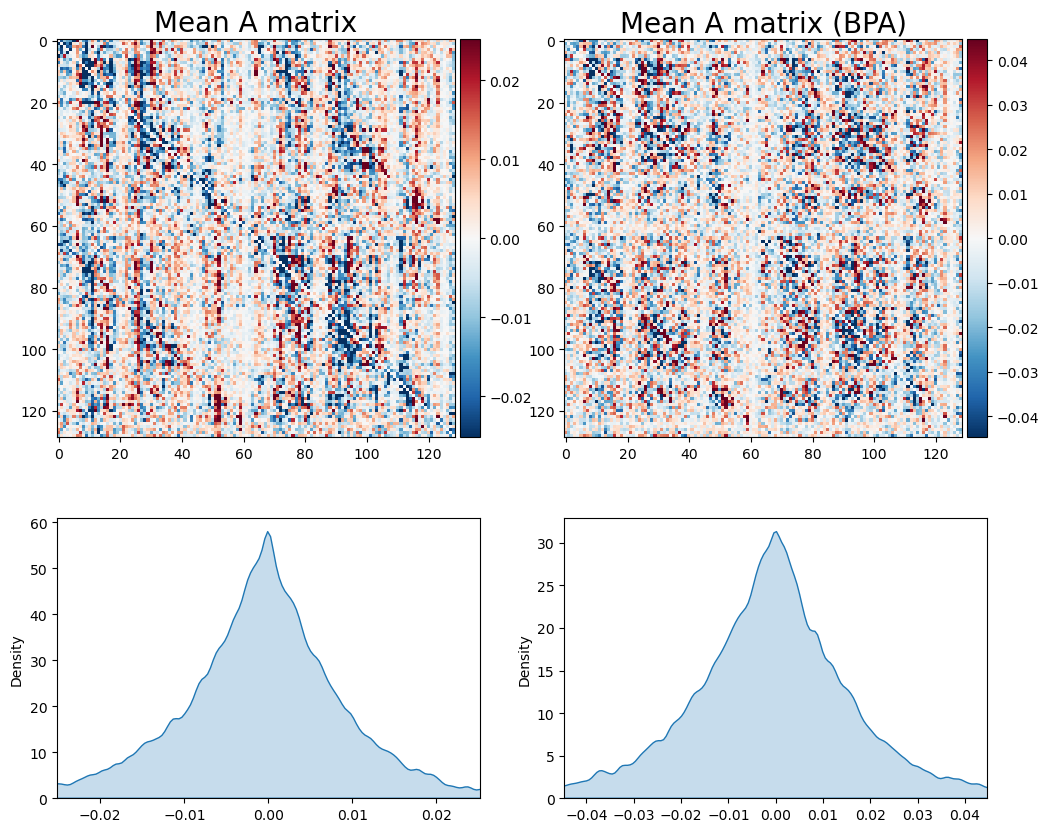

In [44]:
from seaborn import kdeplot

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 2]})

maxprop = 0.3

meanmat = np.mean(all_A_mats, axis=0)
maxval = np.max(np.abs(meanmat))*maxprop
axes[0, 0].set_title("Mean A matrix", fontsize=20)
axes[0, 0].imshow(meanmat, cmap="RdBu_r", vmin=-maxval, vmax=maxval)
add_cbar(fig, axes[0, 0])

kdeplot(meanmat.flatten(), ax=axes[1, 0], bw_adjust=0.3, fill=True, gridsize=500)
axes[1, 0].set_xlim([-maxval, maxval])

meanmat = np.mean(all_A_mats_bpa, axis=0)
maxval = np.max(np.abs(meanmat))*maxprop
axes[0, 1].set_title("Mean A matrix (BPA)", fontsize=20)
axes[0, 1].imshow(meanmat, cmap="RdBu_r", vmin=-maxval, vmax=maxval)
add_cbar(fig, axes[0, 1])

kdeplot(meanmat.flatten(), ax=axes[1, 1], bw_adjust=0.3, fill=True, gridsize=500)
axes[1, 1].set_xlim([-maxval, maxval])

Density of coherent: 38.435
Density of absolute: 50.748


<Axes: ylabel='Density'>

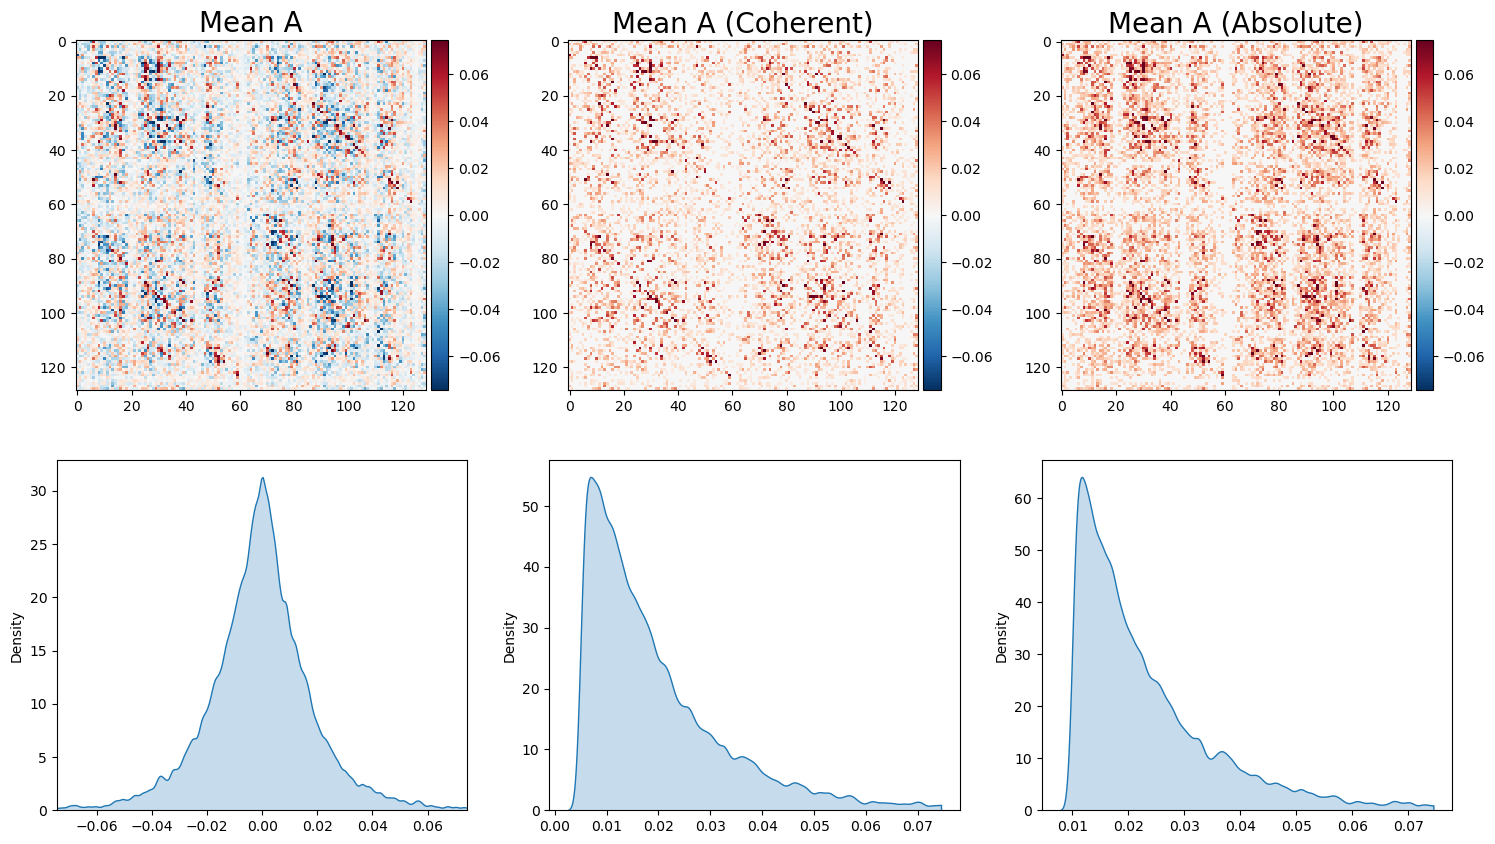

In [84]:
## Handling negative values
group_mean = np.mean(all_A_mats_bpa, axis=0)

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))

maxprop = 0.5

maxval = np.max(np.abs(group_mean))*maxprop
axes[0, 0].set_title("Mean A", fontsize=20)
axes[0, 0].imshow(group_mean, cmap="RdBu_r", vmin=-maxval, vmax=maxval, interpolation="none")
add_cbar(fig, axes[0, 0])

kdeplot(group_mean.flatten(), ax=axes[1, 0], bw_adjust=0.3, fill=True, gridsize=500)
axes[1, 0].set_xlim([-maxval, maxval])

mean_coher = np.zeros_like(group_mean)
coherent_sign = group_mean * group_mean.T > 0
mean_coher[coherent_sign] = np.abs(group_mean[coherent_sign])

# coher_threshold = np.percentile(mean_coher.flatten(), 50)
mean_coher[mean_coher < 0.005] = 0

coher_density = 100*np.sum(mean_coher > 0) / mean_coher.size
print(f"Density of coherent: {coher_density:.3f}")

maxval = np.max(np.abs(mean_coher))*maxprop
axes[0, 1].set_title("Mean A (Coherent)", fontsize=20)
axes[0, 1].imshow(mean_coher, cmap="RdBu_r", vmin=-maxval, vmax=maxval, interpolation="none")
add_cbar(fig, axes[0, 1])

kdeplot(mean_coher[mean_coher > 0], ax=axes[1, 1], bw_adjust=0.3, fill=True, gridsize=500, clip=(0, maxval))

mean_abs = group_mean.copy()
# group_noneg[group_noneg < 0] = 0
mean_abs = np.abs(mean_abs)

abs_threshold = np.percentile(mean_abs.flatten(), 50)
mean_abs[mean_abs < 0.01] = 0

print(f"Density of absolute: {100*np.sum(mean_abs > 0) / mean_abs.size:.3f}")

maxval = np.max(np.abs(mean_abs))*maxprop
axes[0, 2].set_title("Mean A (Absolute)", fontsize=20)
axes[0, 2].imshow(mean_abs, cmap="RdBu_r", vmin=-maxval, vmax=maxval, interpolation="none")
add_cbar(fig, axes[0, 2])

kdeplot(mean_abs[mean_abs > 0], ax=axes[1, 2], bw_adjust=0.3, fill=True, gridsize=500, clip=(0, maxval))

1.0
1.0


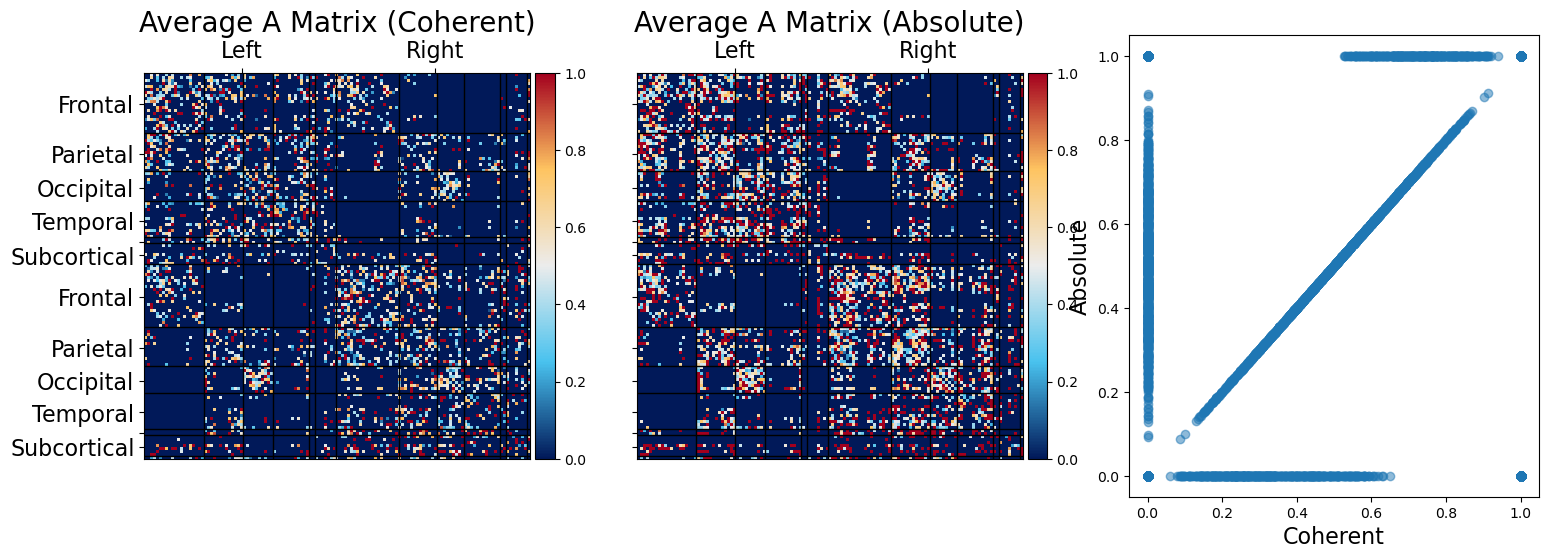

In [88]:
scale = 2

struct_type = ""
use_delay = False
k_threshold = 0
b_thresh = 0.5
# b_thresh = 0
slines_threshold = 5

k_matrix, labels, node_centers = dload.load_bundle_graph(path_to_data=path_to_sc,
                                                             data_suffix="Laus2018_",
                                                             scale=scale,
                                                             b_prob_threshold=b_thresh,
                                                             slines_threshold=slines_threshold,
                                                             log_slines=False,
                                                             normalize_slines=False,
                                                             verbose=False)

labels, k_matrix = b_utils.fix_thalamus(labels, matrix=k_matrix)
k_matrix[k_matrix < b_thresh] = 0
order_by_lobe, lobe_sizes, lobe_labels, lobe_df = dload.get_lobe_info(2, labels, path_to_lobe=path_to_lobe)

np.fill_diagonal(k_matrix, 0)

# ec_mat = dload.get_ec_data(scale=scale, path_to_ec=path_to_ec, remove_neg=True, fix_thal=True, verbose=False, new=False)

fig, axes = plt.subplots(ncols=3, figsize=(18, 6))

gaphs = []
for i, ec_mat in enumerate([mean_coher, mean_abs]):
    np.fill_diagonal(ec_mat, 0)

    # ec_mat[ec_mat > 0] = 0
    # ec_mat = np.abs(ec_mat)
    ec_mat /= ec_mat.max()
    # ec_mat = ec_mat ** gamma

    dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                        where=(ec_mat + ec_mat.T) > 1e-5,
                        out=np.zeros_like(ec_mat))
    graph = (k_matrix > 0) * dir_ratio

    gaphs.append(graph)

    vmax = np.max(graph)
    print(vmax)

    axes[i].set_title("Average A Matrix" + [" (Coherent)", " (Absolute)"][i], fontsize=20)

    axes[i].imshow(graph[order_by_lobe][:, order_by_lobe], interpolation="none", cmap=cmaps["div_rb"],
                   vmin=1 - vmax, vmax=vmax)
    _, _, cbar = add_cbar(fig, axes[i])
    plot_lobe_lines(axes[i], lobe_sizes, lobe_labels, no_insula=True, x_hemi=True, fontsize=16, grid_color="k")

    if i > 0:
        axes[i].set_yticklabels([])

axes[-1].scatter(gaphs[0].flatten(), gaphs[1].flatten(), alpha=0.5)
axes[-1].set_xlabel("Coherent", fontsize=16)
axes[-1].set_ylabel("Absolute", fontsize=16)

ec_coher = True
if ec_coher:
    ec_mat = mean_coher.copy()
    ec_name = "Coherent"
else:
    ec_mat = mean_abs.copy()
    ec_name = "Absolute"

np.fill_diagonal(ec_mat, 0)
ec_mat /= ec_mat.max()
# ec_mat = ec_mat ** gamma

dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                    where=(ec_mat + ec_mat.T) > 1e-5,
                    out=np.zeros_like(ec_mat))
graph = (k_matrix > 0) * dir_ratio

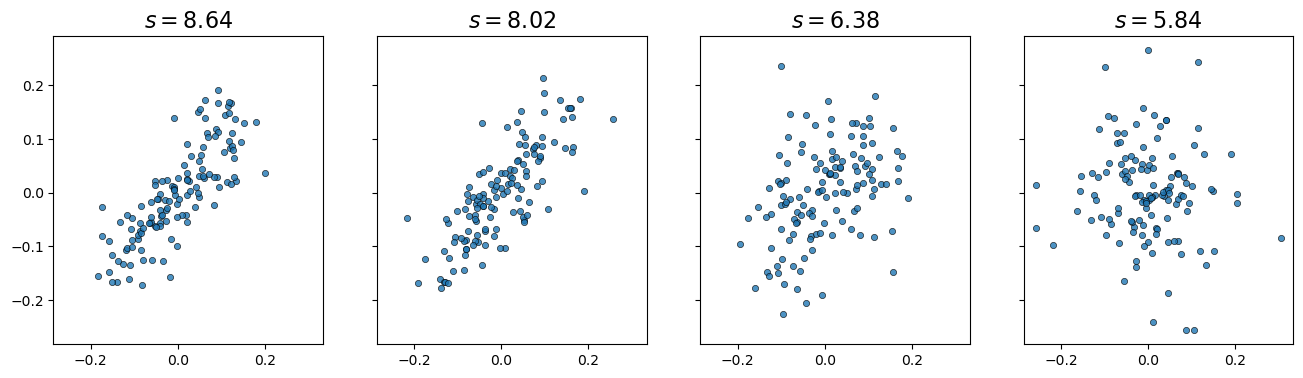

In [89]:
U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
V = Vh.T

n_patterns = 4
fig, axes = plt.subplots(ncols=n_patterns, figsize=(4*n_patterns, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    ax.scatter(U[:, i], V[:, i], s=20, alpha=0.8, edgecolor="k", lw=0.5)
    ax.set_title(f"$s={S[i]:.2f}$", fontsize=16)

# Consensus Clustering

In [90]:
importlib.reload(b_utils)
importlib.reload(dgsp)

scale = 2

struct_type = ""
use_delay = False
k_threshold = 0
b_thresh = 0.5
# b_thresh = 0
slines_threshold = 5

n_trials = 50
n_init = 50
dthresh = 0
selected_sort = 0

undirected = False
nosquared = False

run_fix = False
if undirected:
    run_fix = True

all_n_kmeans = np.arange(10, 80, 1)
all_nvecs = [20]
# gamma = 1

maxjobs = 20

path_to_consensus_task = op.join(
    path_to_derivatives,
    "consensus_clustering",
    task_name.replace("DMN_AROMA_", "")+f"_{ec_name}"
    )
os.makedirs(path_to_consensus_task, exist_ok=True)

for n_vec_max in all_nvecs:
    k_matrix, labels, node_centers = dload.load_bundle_graph(path_to_data=path_to_sc,
                                                             data_suffix="Laus2018_",
                                                             scale=scale,
                                                             b_prob_threshold=b_thresh,
                                                             slines_threshold=slines_threshold,
                                                             log_slines=False,
                                                             normalize_slines=False,
                                                             verbose=False)

    labels, k_matrix = b_utils.fix_thalamus(labels, matrix=k_matrix)
    k_matrix[k_matrix < b_thresh] = 0

    np.fill_diagonal(k_matrix, 0)

    if undirected:
        graph = ((k_matrix + k_matrix.T) / 2 > 0).astype(int)
    else:
        # ec_mat = dload.get_ec_data(scale=scale, path_to_ec=path_to_ec, remove_neg=True, fix_thal=True, verbose=False, new=False)
        # ec_mat /= ec_mat.max()
        # ec_mat = ec_mat ** gamma

        dir_ratio = np.divide(ec_mat, (ec_mat + ec_mat.T),
                            where=(ec_mat + ec_mat.T) > 1e-5,
                            out=np.zeros_like(ec_mat))
        graph = (k_matrix > 0) * dir_ratio

    U, S, Vh = dgsp.sorted_SVD(dgsp.modularity_matrix(graph))
    V = Vh.T

    n_nodes = len(S)
    
    if nosquared:
        scale_factor = S[:n_vec_max]
    else:
        scale_factor = S[:n_vec_max] ** 2

    all_labels = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=np.int8)
    all_labels_fix = np.zeros((len(all_n_kmeans), n_trials, np.sum(graph != 0)), dtype=np.int8)

    cons_lab = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=np.int8)
    cons_lab_fix = np.zeros((len(all_n_kmeans), np.sum(graph != 0)), dtype=np.int8)

    all_c_within = np.zeros(len(all_n_kmeans))
    all_c_between = np.zeros(len(all_n_kmeans))

    all_c_within_fix = np.zeros(len(all_n_kmeans))
    all_c_between_fix = np.zeros(len(all_n_kmeans))

    avg_cons = np.zeros((np.sum(graph != 0), np.sum(graph != 0)), dtype=int)
    avg_cons_fix = np.zeros((np.sum(graph != 0), np.sum(graph != 0)), dtype=int)
    reorder = False

    bm_fname = "_".join([
        f"brain_consensus-EC",
        f"scale{scale}",
        f"nvec{n_vec_max}" + "-NoSquared"*nosquared,
        f"trials{n_trials}",
        f"ninit{n_init}",
        f"kmeans{all_n_kmeans[0]}-{all_n_kmeans[-1]}",
        f"slines_thresh{slines_threshold}",
        f"b_thresh{b_thresh}"*(b_thresh != 0),
        f"ustruct{struct_type}"*(struct_type != ""),
        f"dthresh{dthresh}"*(dthresh != 0),
        f"selected{selected_sort}"*(selected_sort != 0),
        ])
    bm_fname += ".pkl"

    if undirected:
        bm_fname = "Undir_" + bm_fname

    if op.isfile(op.join(path_to_consensus_task, bm_fname)):
        data = dload.load(op.join(path_to_consensus, bm_fname))
        graph = data["graph"]
        all_n_kmeans = data["all_n_kmeans"]
        cons_lab = data["cons_lab"]
        cons_lab_fix = data["cons_lab_fix"]
        all_c_within = data["all_c_within"]
        all_c_between = data["all_c_between"]
        all_c_within_fix = data["all_c_within_fix"]
        all_c_between_fix = data["all_c_between_fix"]
        avg_cons = data["avg_cons"]
        avg_cons_fix = data["avg_cons_fix"]

        # # Override the anatomical bundle correspondence
        # edge_to_bundle_mat = b_utils.get_edge_to_bundle(graph, scale, labels, overlap_thresh=0.1)
        dload.save(op.join(path_to_consensus, bm_fname),
                    {"graph": graph,
                    "all_n_kmeans": all_n_kmeans,
                    "cons_lab": cons_lab,
                    "cons_lab_fix": cons_lab_fix,
                    "all_c_within": all_c_within,
                    "all_c_between": all_c_between,
                    "all_c_within_fix": all_c_within_fix,
                    "all_c_between_fix": all_c_between_fix,
                    "avg_cons": avg_cons,
                    "avg_cons_fix": avg_cons_fix,
                    # "edge_to_bundle_mat": edge_to_bundle_mat
                    })
    elif op.isfile(op.join(path_to_consensus_task, bm_fname.replace(".pkl", ".pkl.gz"))):
        print("Found gzipped version of the file! Skipping.")

        # os.system(f"gunzip -k {op.join(path_to_consensus, bm_fname.replace('.pkl', '.pkl.gz'))}")
        
        # data = dload.load(op.join(path_to_consensus, bm_fname))
        # graph = data["graph"]
        # all_n_kmeans = data["all_n_kmeans"]
        # cons_lab = data["cons_lab"]
        # cons_lab_fix = data["cons_lab_fix"]
        # all_c_within = data["all_c_within"]
        # all_c_between = data["all_c_between"]
        # all_c_within_fix = data["all_c_within_fix"]
        # all_c_between_fix = data["all_c_between_fix"]
        # avg_cons = data["avg_cons"]
        # avg_cons_fix = data["avg_cons_fix"]

        # os.system(f"rm {op.join(path_to_consensus, bm_fname.replace('.pkl', '.pkl.gz'))}")
    else:

        njobs = 1

        parallel = Parallel(n_jobs=np.min([maxjobs, n_trials]), return_as="generator_unordered")
        counter = tqdm(total=len(all_n_kmeans)*n_trials)

        t_cl = []
        t_co = []
        t_fast = []
        t_cs = []

        # for k_i, n_kmeans in tqdm(enumerate(all_n_kmeans), total=len(all_n_kmeans)):
        for k_i, n_kmeans in enumerate(all_n_kmeans):
            t_1 = perf_counter()
            gen = parallel(delayed(dgsp.edge_bicommunities)(
                graph, U, V, 
                n_vec_max,
                method="kmeans",
                n_kmeans=n_kmeans,
                verbose=False,
                max_k=50,
                scale_S=scale_factor,
                clust_only=True,
                # undirected=True,
                undirected=False,
                kwargs_kmeans1={"n_init":n_init, "init":"random"},
                kwargs_kmeans2={"n_init":1, "tol":1e-10},
                dthresh=dthresh,
                ) for _ in range(n_trials))
            
            for t, labs in enumerate(gen):
                all_labels[k_i, t] = labs[0]
                # all_labels_fix[k_i, t] = labs[1]
                all_labels_fix[k_i, t] = 0
                counter.update(1)

            t_2 = perf_counter()
            t_cl.append(t_2 - t_1)
            # print(f"Clustering took {t_cl[-1]:.2f} seconds (mean: {np.mean(t_cl):1.2f} s)")

            cons, cons_lab[k_i] = dgsp.consensus_matrix(all_labels[k_i], reorder=reorder, consensus_labels=True, fast=True, njobs=njobs)
            if run_fix:
                cons_fix, cons_lab_fix[k_i] = dgsp.consensus_matrix(all_labels_fix[k_i], reorder=reorder, consensus_labels=True, fast=True, njobs=njobs)

            t_3 = perf_counter()
            t_co.append(t_3 - t_2)
            # print(f"Consensus matrix computation took {t_co[-1]:.2f} seconds (mean: {np.mean(t_co):1.2f} s)")

            avg_cons += cons
            if run_fix:
                avg_cons_fix += cons_fix

            # all_c_within[k_i], all_c_between[k_i] = dgsp.consensus_score(cons, cons_lab[k_i], is_sorted=not reorder)
            # if run_fix:
            #     all_c_within_fix[k_i], all_c_between_fix[k_i] = dgsp.consensus_score(cons_fix, cons_lab_fix[k_i], is_sorted=not reorder)

            t_4 = perf_counter()
            t_cs.append(t_4 - t_3)
            # print(f"Consensus score took {t_cs[-1]:.2f} seconds (mean: {np.mean(t_cs):1.2f} s)")

        avg_cons = avg_cons.astype(float) / (len(all_n_kmeans) * n_trials)
        if run_fix:
            avg_cons_fix = avg_cons_fix.astype(float) / (len(all_n_kmeans) * n_trials)
        else:
            avg_cons_fix = None

        print(f"Consensus Clustering Done")
        print(f"\t- Clustering took {np.mean(t_cl):1.2f}s on average")
        print(f"\t- Consensus Matrix took {np.mean(t_co):1.2f}s on average")
        print(f"\t- Consensus Score took {np.mean(t_cs):1.2f}s on average")

        counter.close()

        # edge_to_bundle_mat = b_utils.get_edge_to_bundle(graph, scale, labels, overlap_thresh=0.1)

        dload.save(op.join(path_to_consensus_task, bm_fname),
                    {"graph": graph,
                    "all_n_kmeans": all_n_kmeans,
                    "cons_lab": cons_lab,
                    "cons_lab_fix": cons_lab_fix,
                    # "all_c_within": all_c_within,
                    # "all_c_between": all_c_between,
                    # "all_c_within_fix": all_c_within_fix,
                    # "all_c_between_fix": all_c_between_fix,
                    "avg_cons": avg_cons,
                    "avg_cons_fix": avg_cons_fix,
                    # "edge_to_bundle_mat": edge_to_bundle_mat
                    })

  0%|          | 0/3500 [00:00<?, ?it/s]

Consensus Clustering Done
	- Clustering took 1.75s on average
	- Consensus Matrix took 0.48s on average
	- Consensus Score took 0.01s on average
